# TFIM / Heisenberg chain のハミルトニアンシミュレーション回路資源比較

Open TFIM と open XXX Heisenberg chain に対する Trotter–Suzuki、QSVT、multiproduct formula (MPF) を、同じ Pauli 和と誤差予算の下で比較します。小規模系では実際の statevector、大規模系では密行列を作らないゲート分解モデルを使います。

MPF branch count は固定次数や有限候補の最適化ではなく、Mizuta Theorem 6 の repository 実装

$$
J=\max\!\left(2,\left\lceil\frac12\log\frac{Ng|t|}{\epsilon_{\rm alg}}\right\rceil\right),
\qquad m_{\rm paper}=2J,
$$

で point ごとに1回だけ決めます。ここで $\epsilon_{\rm alg}=(1-\text{synthesis fraction})\epsilon$ です。$J\le15$ では全 estimator が同じ explicit schedule を使います。$J>15$ では schedule を捏造せず、Low と `best-rigorous-ideal` だけが $\lVert a\rVert_1\le2$ と aggregate $\sum_jk_j$ を使い、legacy/refined Mizuta は explicit branch data 不足として停止します。$J$ 自体は数値最適化しません。

この validation pass は計算時間を管理するため **TFIM のみ実行**します。Heisenberg/XXX の物理定義と実行コードは後半に残していますが、`RUN_HEISENBERG=False` で明示的に無効化しています。


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dataclasses import asdict
from pathlib import Path
import json
import math
import sys
import time

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

root = Path.cwd().resolve()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root / 'src'))

from hamiltonian_resources import (  # noqa: E402
    BenchmarkConfig,
    HamiltonianSpec,
    MultiproductMethod,
    QSVTMethod,
    TimeScaling,
    TrotterMethod,
    build_simulation_circuit,
    compare_plan_with_exact,
    estimate_resources,
    load_benchmark,
    pauli_locality_parameters,
    plot_benchmark,
    run_benchmark,
    transverse_field_ising,
)
pd.set_option("display.max_columns", None)


c:\Users\xiang\Documents\numerical_calculation\001_hamiltonian_simulation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. グローバルに使うベンチマーク設定

System-size は 5 から 100 までの重複しない rounded log grid です。Target-error sweep は既存の $10^{-1}$ から $10^{-20}$ を保ちます。Theorem-6 policy が explicit schedule table の上限 $J=15$ を超えても clamp しません。Low と best-rigorous は aggregate analytical row を継続し、legacy/refined Mizuta は明示的な unavailable error row を残します。


In [3]:
SYSTEM_SIZES = np.rint(np.geomspace(5, 100, num=20)).astype(np.int_)
TARGET_ERRORS = np.logspace(-1, -20, 20)
TIME_PER_QUBIT = 1.0
FIXED_SYSTEM_SIZE = 50
FIXED_TARGET_ERROR = 1e-3
SYNTHESIS_ERROR_FRACTION = 0.1
RUN_HEISENBERG = False

MPF_ERROR_METHODS = {
    "Low 2019": "low2019-l1-ideal-rigorous",
    "Mizuta legacy Theorem 3": "mizuta2026-theorem3-legacy-ideal-rigorous",
    "Mizuta refined": "mizuta2026-commutator-ideal-rigorous",
    "Best rigorous ideal": "best-rigorous-ideal",
}
MPF_METHODS = [
    MultiproductMethod(
        term_count=None,
        branch_count_policy="mizuta2026-theorem6",
        error_method=error_method,
    )
    for error_method in MPF_ERROR_METHODS.values()
]
AGGREGATE_ANALYTICAL_METHOD_IDS = {
    method.method_id
    for method in MPF_METHODS
    if method.error_method in {
        "low2019-l1-ideal-rigorous", "best-rigorous-ideal"
    }
}
BENCHMARK_METHODS = [
    *(TrotterMethod(order) for order in (1, 2, 4, 6)),
    *MPF_METHODS,
    QSVTMethod(),
]

# Each sweep is saved independently. An interrupted run can resume from the
# completed sweep without recomputing it; benchmark_outputs is git-ignored.
CHECKPOINT_DIRECTORY = root / "benchmark_outputs" / "resource_comparison_checkpoints"
CHECKPOINT_SCHEMA = "aggregate-mpf-v1"

assert len(SYSTEM_SIZES) == len(set(SYSTEM_SIZES)) == 20
assert (SYSTEM_SIZES[0], SYSTEM_SIZES[-1]) == (5, 100)


## 1. ハミルトニアン入力

実行する単一点例は open TFIM
$H=J\sum_i Z_iZ_{i+1}+h\sum_iX_i$ とします。後半に残した disabled cell では open XXX Heisenberg chain
$H=J\sum_i(X_iX_{i+1}+Y_iY_{i+1}+Z_iZ_{i+1})+h_z\sum_iZ_i$
を同じ API で構成します。どちらの物理モデル定義も変更しません。


In [4]:
H = transverse_field_ising(
    3, coupling=1.0, field=3.0, periodic=False
)
print(H.name, H.terms)
print(f"terms={H.term_count}, alpha=sum|h_j|={H.alpha:.3f}")


TFIM-3 (('IZZ', -1.0), ('ZZI', -1.0), ('IIX', -3.0), ('IXI', -3.0), ('XII', -3.0))
terms=5, alpha=sum|h_j|=11.000


## 2. 単一点resource評価とalgorithm plan

`estimate_resources` は Hamiltonian・手法・時刻・目標誤差から parameter を1回だけ選択し、backend 非依存の immutable plan と構造化解析resource結果を返します。次の refined-Mizuta MPF 例も `term_count=None` です。`selected_parameters` と sizing estimate は resolved $J$、formal order $2J$、policy、$g$、policy error budget を記録します。Refined estimator は $p_0\ge2J$ を保持します。

Ideal MPF の目標が certified でも、実装する repeated shared-ancilla good block の保守的な上界は同じ目標を満たさない場合があります。resource 見積りは後者の実回路構成に対応します。


In [5]:
point_report = estimate_resources(
    H,
    MultiproductMethod(
        None,
        branch_count_policy="mizuta2026-theorem6",
        error_method="mizuta2026-commutator-ideal-rigorous",
    ),
    time=0.2,
    target_error=1e-3,
)

analysis = point_report.error_analysis
point_diagnostics = point_report.plan.error_estimate.segment_diagnostics

display(pd.Series({
    "selected_parameters": point_report.selected_parameters,
    "error_budget": {
        "algorithm": point_report.error_budget.algorithm_error,
        "synthesis": point_report.error_budget.synthesis_error,
    },
    "policy_extensiveness_g": point_report.plan.branch_count_selection.extensiveness_g,
    "coefficient_l1_norm": point_report.plan.lcu_structure.coefficient_l1_norm,
    "exponent_sum": sum(point_report.plan.exponents),
    "truncation_order_p0": point_diagnostics.truncation_order_p0,
    "active_constraints": point_diagnostics.active_constraints,
    "parameter_selection_succeeded": point_report.parameter_selection_succeeded,
    "ideal_algorithm_target": analysis.ideal_algorithm_target.outcome,
    "implemented_circuit_target": analysis.implemented_circuit_target.outcome,
    "logical_counts": point_report.logical_counts.as_dict(),
    "analytical_resources": point_report.resources.as_dict(),
}, name="single-point dynamic-MPF report"))

display(pd.Series(asdict(analysis.sizing_estimate), name="parameter-selection estimate"))
display(pd.DataFrame([
    {"method": supported.method, **asdict(supported.claim)}
    for supported in analysis.claims
]))

assert point_report.plan.term_count == 5
assert point_report.plan.formal_order == 10
assert point_diagnostics.truncation_order_p0 >= 2 * point_report.plan.term_count


selected_parameters              {'mpf_m': 5, 'mpf_branch_count': 5, 'mpf_forma...
error_budget                     {'algorithm': 0.0009000000000000001, 'synthesi...
policy_extensiveness_g                                                         5.0
coefficient_l1_norm                                                       1.825738
exponent_sum                                                                    23
truncation_order_p0                                                             10
active_constraints                                                        (error,)
parameter_selection_succeeded                                                 True
ideal_algorithm_target                                                   certified
implemented_circuit_target                                                 not_met
logical_counts                   {'totals': {'prepare': 114, 'select': 57, 'goo...
analytical_resources             {'algorithm': 'multiproduct', 'num_qubits': 8,...
Name

value                                                                0.000466
method                                   mizuta2026-commutator-ideal-rigorous
category                                                           analytical
certification                                                        rigorous
quantity                               evolution-operator approximation error
metric                                                        operator-2-norm
scope                                                               ideal-mpf
target                                                                 0.0009
segments                                                                   19
term_count                                                                  5
formal_order                                                               10
branch_count_policy                                       mizuta2026-theorem6
branch_count_policy_extensiveness_g                             

,method,value,category,certification,quantity,metric,scope
0,mizuta2026-commutator-ideal-rigorous,0.000466,analytical,rigorous,evolution-operator approximation error,operator-2-norm,ideal-mpf
1,mizuta2026-commutator-ideal-rigorous-local-step,0.000025,analytical,rigorous,one-segment evolution-operator approximation e...,operator-2-norm,one-segment-ideal-mpf
2,exact-cubic-oaa-unitarity-defect,0.000049,derived,rigorous,amplified good-block approximation error,operator-2-norm,one-segment-amplified-good-block
3,gslw2019-reused-ancilla-product,0.070824,derived,rigorous,repeated projected good-block approximation error,operator-2-norm,repeated-shared-ancilla-good-block


同じplanをreference Qiskit backendと小規模な厳密検証へ渡せます。`compare_plan_with_exact`のstate error、fidelity、success probabilityは、指定した初期状態とpostselection規約を持つ`MetricObservation`であり、operator-norm certificateではありません。Compiled circuit metadataにも selected branch-count policy と policy inputs が保存されます。


In [6]:
point_circuit = build_simulation_circuit(point_report.plan)
point_validation = compare_plan_with_exact(point_report.plan)
point_report = point_report.with_observations(point_validation.observations)

display(pd.Series({
    "reference_circuit_qubits": point_circuit.num_qubits,
    "circuit_branch_count_policy": point_circuit.metadata["branch_count_policy"],
    "circuit_selected_J": point_circuit.metadata["selected_branch_count"],
    "state_error": point_validation["state_error"],
    "fidelity": point_validation["fidelity"],
    "success_probability": point_validation["success_probability"],
}, name="small-system validation"))
display(pd.DataFrame([
    {
        "metric": observation.metric,
        "value": observation.value,
        "scope": observation.scope,
        "state_source": observation.context.initial_state.source,
        "postselection": observation.context.postselection.projector,
    }
    for observation in point_report.observations
]))


reference_circuit_qubits                         6
circuit_branch_count_policy    mizuta2026-theorem6
circuit_selected_J                               5
state_error                                    0.0
fidelity                                       1.0
success_probability                            1.0
Name: small-system validation, dtype: object

,metric,value,scope,state_source,postselection
0,phase-aligned-state-2-norm,1.856526e-12,normalized-postselected-system-state,computational-zero,all non-system registers equal zero
1,pure-state-fidelity,1.000000e+00,normalized-postselected-system-state,computational-zero,all non-system registers equal zero
2,good-subspace-probability,1.000000e+00,raw-circuit-output,computational-zero,all non-system registers equal zero


## 3. TFIM benchmark: checkpointed sweeps and variable MPF order

Theorem-6 $J$ depends on $N,g,t,\epsilon_{\rm alg}$. $J\le15$ では Low、legacy Mizuta、refined Mizuta、best-rigorous が同じ resolved explicit schedule を使います。$J>15$ では Low と best-rigorous が aggregate schedule information を使い、legacy/refined Mizuta は unavailable です。Method order は `Low → legacy → refined → best` とし、explicit range では refined remainder と commutator cache を best policy が再利用できるようにします。

Profiling at TFIM $N=t=50,\epsilon=10^{-3}$ found that Low took about 0.001 s、legacy 0.30 s、refined 8.6 s、warm-cache best 0.08 s。Cold refined profile の約90%は $p_0$/segment search 中の Lemma-10 scalar-flow tail certificate で、Hamiltonian commutator recurrence は1 miss後に再利用されました。したがって rigorous bound を弱めず、各sweepをCSV checkpointに分けて同じkernel/cache内で実行します。


### Transverse-field Ising model (TFIM) — enabled


loaded system-size checkpoint (180 rows) from benchmark_outputs\resource_comparison_checkpoints\tfim_aggregate-mpf-v1_7c4400f630046982_system-size.csv in 0.01 s
loaded target-error checkpoint (180 rows) from benchmark_outputs\resource_comparison_checkpoints\tfim_aggregate-mpf-v1_7c4400f630046982_target-error.csv in 0.01 s


,sweep,system_qubits,evolution_time,target_error,algorithm_error_budget,method_label,mpf_branch_count_policy,mpf_branch_count_policy_extensiveness_g,mpf_term_count,mpf_formal_order,mpf_coefficient_l1_norm,mpf_exponent_sum,mpf_exponent_sum_source,mpf_explicit_schedule_available,segment_count,mpf_truncation_order_p0,mpf_active_constraints_json,mpf_legacy_first_condition_passed,mpf_locality_fallback,mpf_refined_tail_fallback_status,mpf_bound_candidates_json,query_count,bound_method,circuit_bound_rigorous,status,error_message
4,system-size,5,5.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point),mizuta2026-theorem6,5.0,6.0,12.0,1.972128,32.0,registered-exact,True,50.0,NaN,"[""error""]",NaN,NaN,NaN,[],4800.0,low2019-l1-ideal-rigorous,True,ok,NaN
5,system-size,5,5.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point) [M...,mizuta2026-theorem6,5.0,6.0,12.0,1.972128,32.0,registered-exact,True,433848.0,27.0,"[""time_1""]",NaN,NaN,NaN,[],41649408.0,mizuta2026-theorem3-legacy-ideal-rigorous,True,ok,NaN
6,system-size,5,5.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point) [M...,mizuta2026-theorem6,5.0,6.0,12.0,1.972128,32.0,registered-exact,True,586.0,12.0,"[""error""]",False,False,not-used,[],56256.0,mizuta2026-commutator-ideal-rigorous,True,ok,NaN
7,system-size,5,5.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point) [b...,mizuta2026-theorem6,5.0,6.0,12.0,1.972128,32.0,registered-exact,True,50.0,NaN,"[""error""]",NaN,NaN,NaN,"[{""available"":true,""error"":0.00089123078144538...",4800.0,low2019-l1-ideal-rigorous,True,ok,NaN
13,system-size,6,6.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point),mizuta2026-theorem6,5.0,7.0,14.0,1.965530,46.0,registered-exact,True,58.0,NaN,"[""error""]",NaN,NaN,NaN,[],8004.0,low2019-l1-ideal-rigorous,True,ok,NaN
14,system-size,6,6.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point) [M...,mizuta2026-theorem6,5.0,7.0,14.0,1.965530,46.0,registered-exact,True,539900.0,28.0,"[""time_1""]",NaN,NaN,NaN,[],74506200.0,mizuta2026-theorem3-legacy-ideal-rigorous,True,ok,NaN
15,system-size,6,6.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point) [M...,mizuta2026-theorem6,5.0,7.0,14.0,1.965530,46.0,registered-exact,True,710.0,14.0,"[""error""]",False,False,not-used,[],97980.0,mizuta2026-commutator-ideal-rigorous,True,ok,NaN
16,system-size,6,6.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point) [b...,mizuta2026-theorem6,5.0,7.0,14.0,1.965530,46.0,registered-exact,True,58.0,NaN,"[""error""]",NaN,NaN,NaN,"[{""available"":true,""error"":0.00083537599116327...",8004.0,low2019-l1-ideal-rigorous,True,ok,NaN
22,system-size,7,7.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point),mizuta2026-theorem6,5.0,7.0,14.0,1.965530,46.0,registered-exact,True,81.0,NaN,"[""error""]",NaN,NaN,NaN,[],11178.0,low2019-l1-ideal-rigorous,True,ok,NaN
23,system-size,7,7.0,0.001,0.0009,MPF J=Mizuta Theorem 6 (resolved per point) [M...,mizuta2026-theorem6,5.0,7.0,14.0,1.965530,46.0,registered-exact,True,629883.0,28.0,"[""time_1""]",NaN,NaN,NaN,[],86923854.0,mizuta2026-theorem3-legacy-ideal-rigorous,True,ok,NaN


C:\Users\xiang\Documents\numerical_calculation\001_hamiltonian_simulation\src\hamiltonian_resources\benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
C:\Users\xiang\Documents\numerical_calculation\001_hamiltonian_simulation\src\hamiltonian_resources\benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
C:\Users\xiang\Documents\numerical_calculation\001_hamiltonian_simulation\src\hami

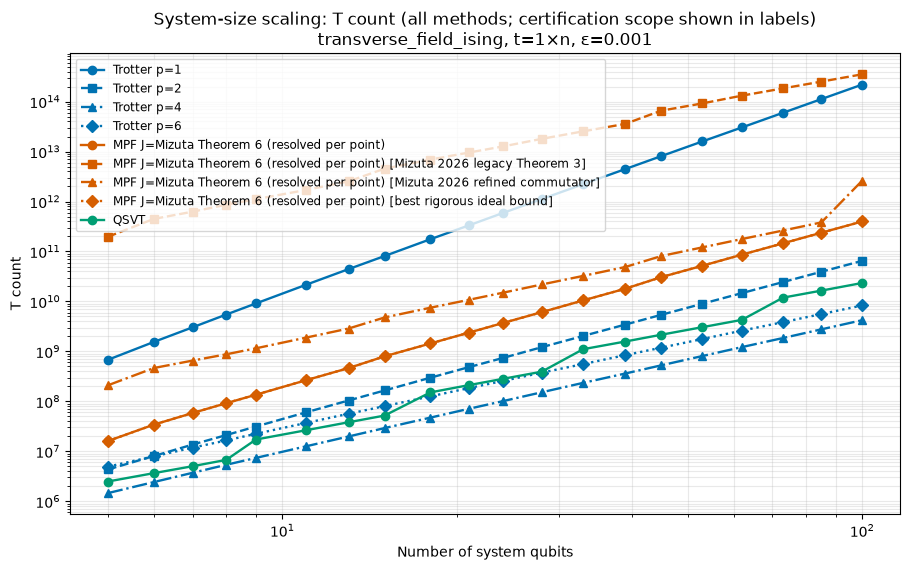

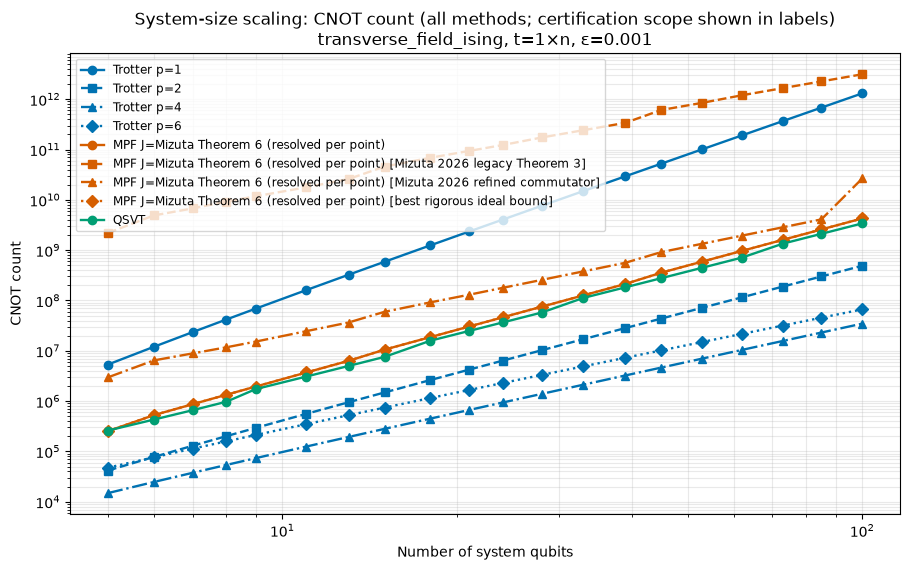

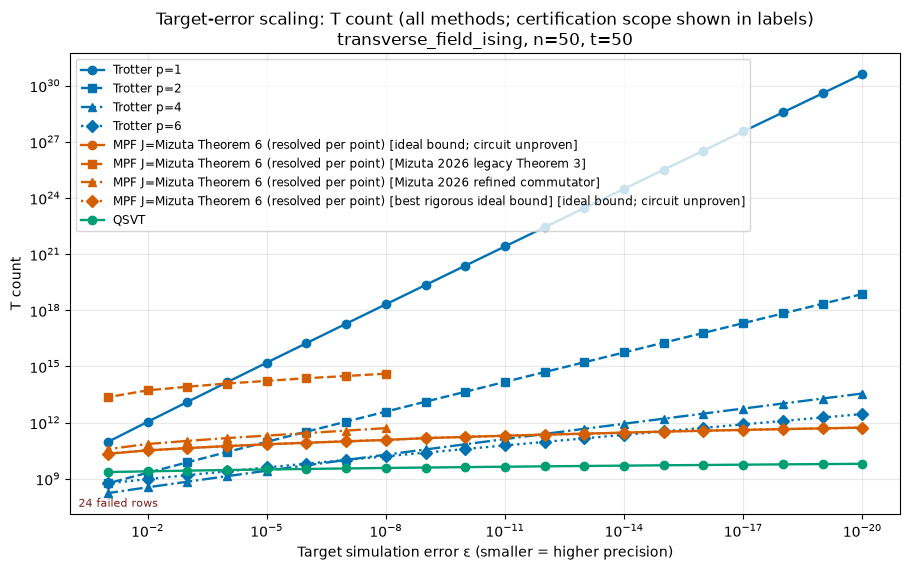

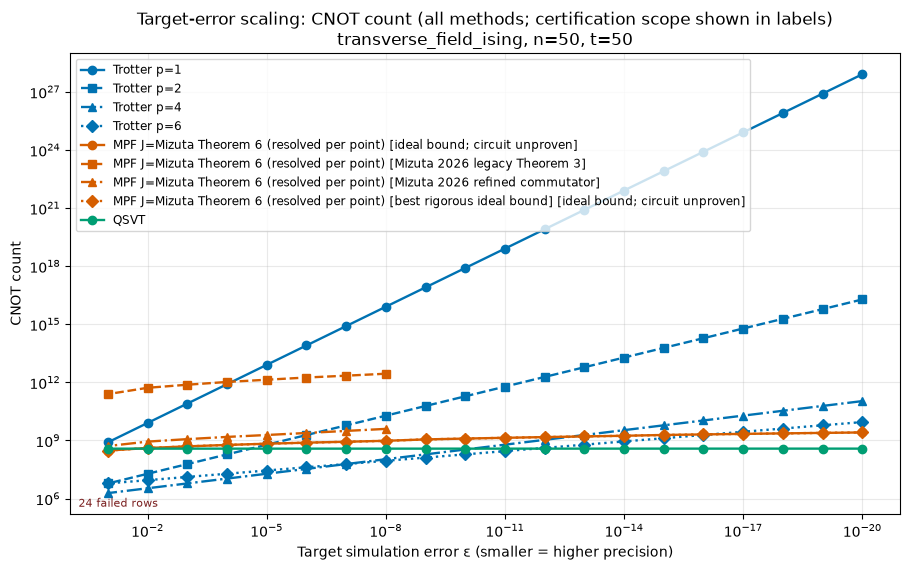

In [7]:
def run_checkpointed_sweep(config, sweep, model_slug):
    checkpoint = (
        CHECKPOINT_DIRECTORY
        / f"{model_slug}_{CHECKPOINT_SCHEMA}_{config.digest[:16]}_{sweep}.csv"
    )
    if checkpoint.exists():
        started = time.perf_counter()
        data = load_benchmark(checkpoint)
        print(
            f"loaded {sweep} checkpoint ({len(data)} rows) "
            f"from {checkpoint.relative_to(root)} in "
            f"{time.perf_counter() - started:.2f} s"
        )
        return data

    started = time.perf_counter()
    data = run_benchmark(
        config,
        sweeps=sweep,
        workers=4,
        show_progress=True,
    )
    checkpoint.parent.mkdir(parents=True, exist_ok=True)
    data.to_csv(checkpoint, index=False, na_rep="")
    print(
        f"computed {sweep} checkpoint ({len(data)} rows) "
        f"in {time.perf_counter() - started:.2f} s: "
        f"{checkpoint.relative_to(root)}"
    )
    return data


def add_mpf_audit_columns(data):
    enriched = data.copy()

    def exponent_sum(raw):
        if pd.isna(raw):
            return np.nan
        return sum(json.loads(str(raw)))

    explicit_exponent_sum = enriched["mpf_exponents_json"].map(exponent_sum)
    explicit_rows = explicit_exponent_sum.notna()
    assert np.allclose(
        enriched.loc[explicit_rows, "mpf_exponent_sum"].astype(float),
        explicit_exponent_sum[explicit_rows].astype(float),
    )
    return enriched


benchmark_config_ising = BenchmarkConfig(
    hamiltonian=HamiltonianSpec(
        model="transverse_field_ising",
        parameters={"coupling": 1.0, "field": 3.0, "periodic": False},
    ),
    system_sizes=SYSTEM_SIZES,
    target_errors=TARGET_ERRORS,
    time=TimeScaling("proportional", TIME_PER_QUBIT),
    fixed_system_size=FIXED_SYSTEM_SIZE,
    fixed_target_error=FIXED_TARGET_ERROR,
    methods=BENCHMARK_METHODS,
    synthesis_error_fraction=SYNTHESIS_ERROR_FRACTION,
)

tfim_system_size = run_checkpointed_sweep(
    benchmark_config_ising, "system-size", "tfim"
)
tfim_target_error = run_checkpointed_sweep(
    benchmark_config_ising, "target-error", "tfim"
)
benchmark_data_ising = add_mpf_audit_columns(
    pd.concat([tfim_system_size, tfim_target_error], ignore_index=True)
)

MPF_AUDIT_COLUMNS = [
    "sweep", "system_qubits", "evolution_time", "target_error",
    "algorithm_error_budget", "method_label", "mpf_branch_count_policy",
    "mpf_branch_count_policy_extensiveness_g", "mpf_term_count",
    "mpf_formal_order", "mpf_coefficient_l1_norm", "mpf_exponent_sum",
    "mpf_exponent_sum_source", "mpf_explicit_schedule_available",
    "segment_count", "mpf_truncation_order_p0", "mpf_active_constraints_json",
    "mpf_legacy_first_condition_passed", "mpf_locality_fallback",
    "mpf_refined_tail_fallback_status", "mpf_bound_candidates_json",
    "query_count", "bound_method", "circuit_bound_rigorous",
    "status", "error_message",
]
display(
    benchmark_data_ising[
        benchmark_data_ising["method_family"].eq("multiproduct")
    ][MPF_AUDIT_COLUMNS].head(20)
)

detailed_figures_ising = (
    plot_benchmark(benchmark_data_ising, sweep="system-size", metric="t_count"),
    plot_benchmark(benchmark_data_ising, sweep="system-size", metric="cnot_count"),
    plot_benchmark(benchmark_data_ising, sweep="target-error", metric="t_count"),
    plot_benchmark(benchmark_data_ising, sweep="target-error", metric="cnot_count"),
)


#### Theorem-6 selected-order sequences and order-aware plots

Target-error sweep では $J$ 自体が accuracy とともに変わるため、固定次数の $\epsilon^{-1/(2J)}$ law は主張しません。Prescribed $J$ sequence と、同じ dynamic order における Low/Mizuta resource curves を併記します。


,sweep,N,time,target_error,algorithm_error,g,prescribed_J,formal_order,explicit_schedule_available,aggregate_low_available
0,system-size,5,5.0,0.001,0.0009,5.0,6,12,True,True
1,system-size,6,6.0,0.001,0.0009,5.0,7,14,True,True
2,system-size,7,7.0,0.001,0.0009,5.0,7,14,True,True
3,system-size,8,8.0,0.001,0.0009,5.0,7,14,True,True
4,system-size,9,9.0,0.001,0.0009,5.0,7,14,True,True
5,system-size,11,11.0,0.001,0.0009,5.0,7,14,True,True
6,system-size,13,13.0,0.001,0.0009,5.0,7,14,True,True
7,system-size,15,15.0,0.001,0.0009,5.0,8,16,True,True
8,system-size,18,18.0,0.001,0.0009,5.0,8,16,True,True
9,system-size,21,21.0,0.001,0.0009,5.0,8,16,True,True


,sweep,N,time,target_error,algorithm_error,g,prescribed_J,formal_order,explicit_schedule_available,aggregate_low_available
0,target-error,50,50.0,1.000000e-01,9.000000e-02,5.0,6,12,True,True
1,target-error,50,50.0,1.000000e-02,9.000000e-03,5.0,8,16,True,True
2,target-error,50,50.0,1.000000e-03,9.000000e-04,5.0,9,18,True,True
3,target-error,50,50.0,1.000000e-04,9.000000e-05,5.0,10,20,True,True
4,target-error,50,50.0,1.000000e-05,9.000000e-06,5.0,11,22,True,True
5,target-error,50,50.0,1.000000e-06,9.000000e-07,5.0,12,24,True,True
6,target-error,50,50.0,1.000000e-07,9.000000e-08,5.0,13,26,True,True
7,target-error,50,50.0,1.000000e-08,9.000000e-09,5.0,14,28,True,True
8,target-error,50,50.0,1.000000e-09,9.000000e-10,5.0,16,32,False,True
9,target-error,50,50.0,1.000000e-10,9.000000e-11,5.0,17,34,False,True


TFIM system-size J sequence: [6, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9]
TFIM target-error J sequence: [6, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28]


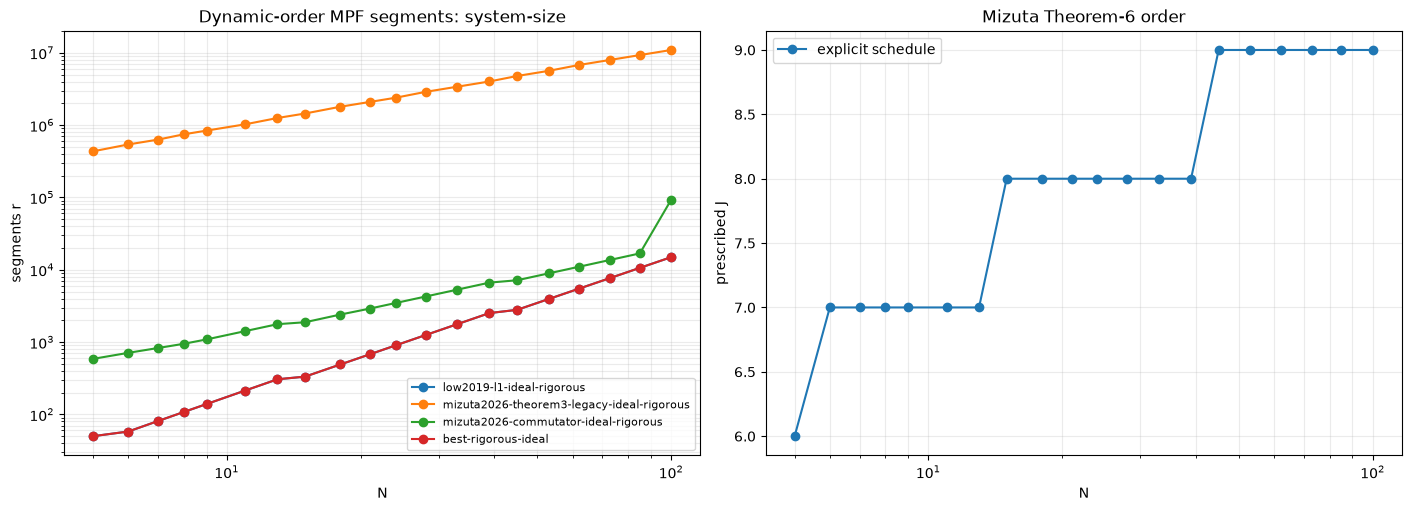

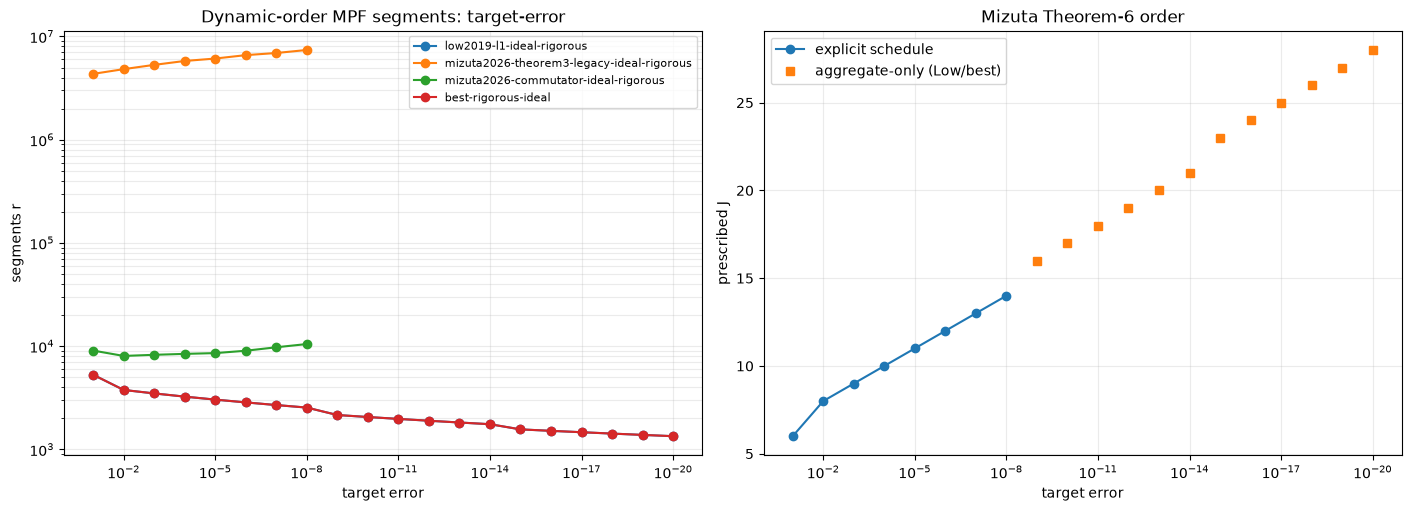

C:\Users\xiang\Documents\numerical_calculation\001_hamiltonian_simulation\src\hamiltonian_resources\benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
C:\Users\xiang\Documents\numerical_calculation\001_hamiltonian_simulation\src\hamiltonian_resources\benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
C:\Users\xiang\Documents\numerical_calculation\001_hamiltonian_simulation\src\hami

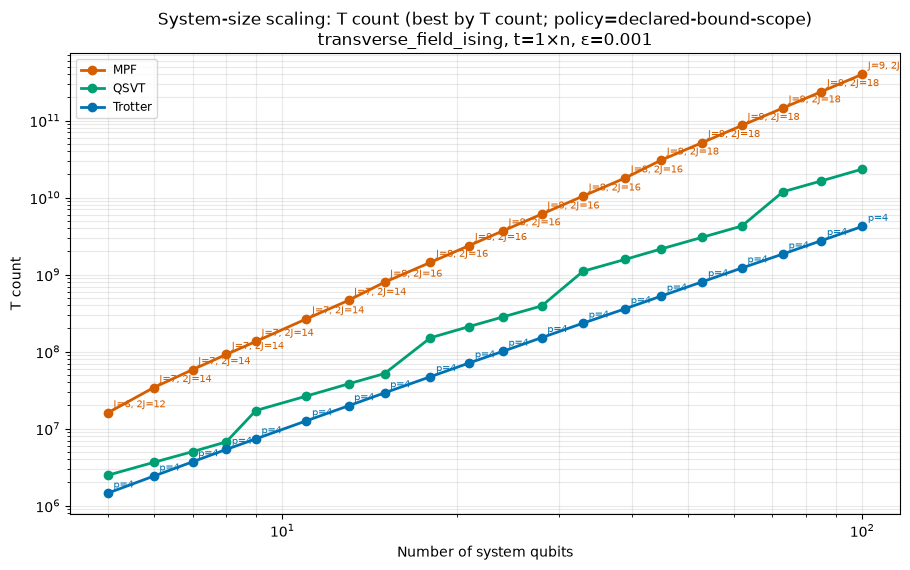

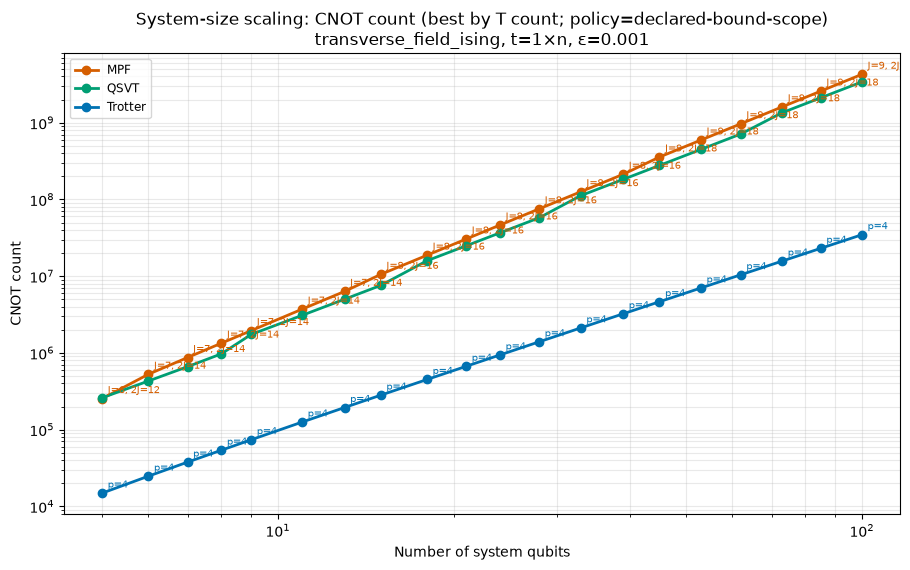

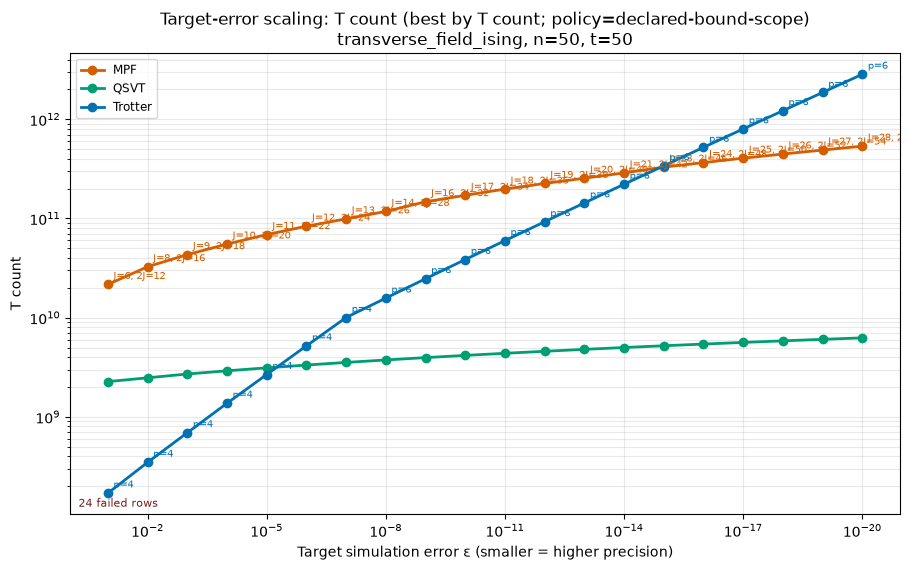

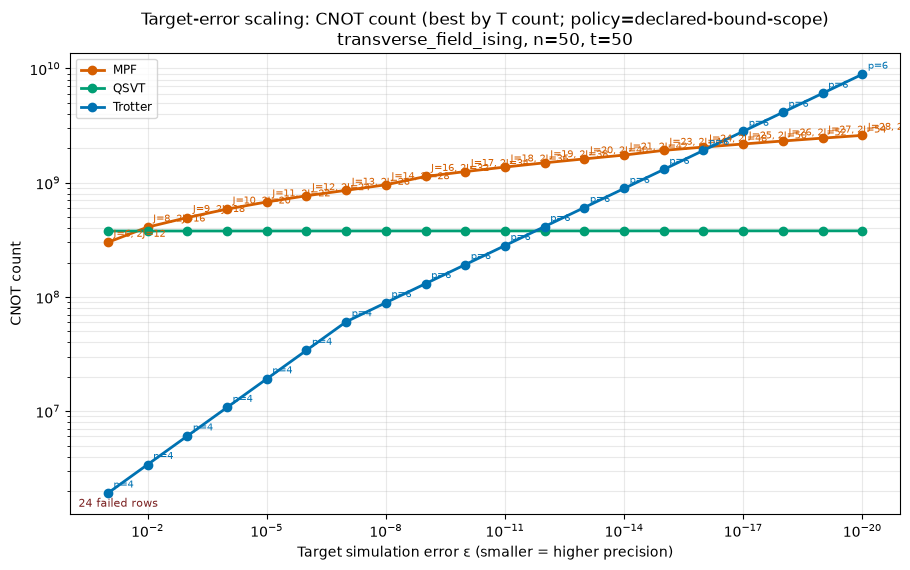

In [8]:
def theorem6_policy_sequence(config, sweep):
    if sweep == "system-size":
        points = [
            (int(size), config.time.at(int(size)), config.fixed_target_error)
            for size in config.system_sizes
        ]
    else:
        points = [
            (
                config.fixed_system_size,
                config.time.at(config.fixed_system_size),
                float(target),
            )
            for target in config.target_errors
        ]

    rows = []
    for size, evolution_time, target_error in points:
        hamiltonian = config.hamiltonian.build(size)
        _, extensiveness_g = pauli_locality_parameters(hamiltonian)
        algorithm_error = target_error * (1 - config.synthesis_error_fraction)
        if extensiveness_g == 0.0 or evolution_time == 0.0:
            selected_j = 2
        else:
            log_ratio = (
                math.log(size)
                + math.log(extensiveness_g)
                + math.log(abs(evolution_time))
                - math.log(algorithm_error)
            )
            selected_j = max(2, math.ceil(0.5 * log_ratio))
        rows.append({
            "sweep": sweep,
            "N": size,
            "time": evolution_time,
            "target_error": target_error,
            "algorithm_error": algorithm_error,
            "g": extensiveness_g,
            "prescribed_J": selected_j,
            "formal_order": 2 * selected_j,
            "explicit_schedule_available": selected_j <= 15,
            "aggregate_low_available": True,
        })
    return pd.DataFrame(rows)


tfim_size_orders = theorem6_policy_sequence(benchmark_config_ising, "system-size")
tfim_target_orders = theorem6_policy_sequence(benchmark_config_ising, "target-error")
display(tfim_size_orders)
display(tfim_target_orders)
print("TFIM system-size J sequence:", tfim_size_orders["prescribed_J"].tolist())
print("TFIM target-error J sequence:", tfim_target_orders["prescribed_J"].tolist())


def plot_dynamic_mpf_segments(data, orders, sweep):
    x_column = "system_qubits" if sweep == "system-size" else "target_error"
    order_x = "N" if sweep == "system-size" else "target_error"
    values = data[
        data["sweep"].eq(sweep)
        & data["method_family"].eq("multiproduct")
        & data["status"].eq("ok")
    ].copy()
    figure, (resource_axis, order_axis) = plt.subplots(
        1, 2, figsize=(14, 5), constrained_layout=True
    )
    for policy, group in values.groupby("mpf_bound_policy", sort=False):
        group = group.sort_values(x_column)
        resource_axis.loglog(
            group[x_column], group["segment_count"], marker="o", label=policy
        )
    explicit = orders[orders["explicit_schedule_available"]]
    aggregate_only = orders[~orders["explicit_schedule_available"]]
    order_axis.semilogx(
        explicit[order_x], explicit["prescribed_J"], marker="o",
        label="explicit schedule",
    )
    if not aggregate_only.empty:
        order_axis.semilogx(
            aggregate_only[order_x], aggregate_only["prescribed_J"],
            linestyle="none", marker="s", markersize=6,
            label="aggregate-only (Low/best)",
        )
    if sweep == "target-error":
        resource_axis.invert_xaxis()
        order_axis.invert_xaxis()
    resource_axis.set(
        xlabel="N" if sweep == "system-size" else "target error",
        ylabel="segments r",
        title=f"Dynamic-order MPF segments: {sweep}",
    )
    order_axis.set(
        xlabel="N" if sweep == "system-size" else "target error",
        ylabel="prescribed J",
        title="Mizuta Theorem-6 order",
    )
    resource_axis.grid(True, which="both", alpha=0.25)
    order_axis.grid(True, which="both", alpha=0.25)
    resource_axis.legend(fontsize=8)
    order_axis.legend()
    plt.show()
    return figure


dynamic_mpf_figures_ising = (
    plot_dynamic_mpf_segments(
        benchmark_data_ising, tfim_size_orders, "system-size"
    ),
    plot_dynamic_mpf_segments(
        benchmark_data_ising, tfim_target_orders, "target-error"
    ),
)

simple_figures_ising = tuple(
    plot_benchmark(
        benchmark_data_ising,
        sweep=sweep,
        metric=metric,
        summary=True,
        selection_metric="t_count",
        certification_policy="declared-bound-scope",
    )
    for sweep in ("system-size", "target-error")
    for metric in ("t_count", "cnot_count")
)


### Heisenberg / XXX comparison — temporarily disabled

The rigorous MPF resource calculation is computationally expensive, so this validation pass does not execute the Heisenberg-chain sweep. The unchanged open-XXX model configuration and re-enable switch remain below.


In [9]:
benchmark_config_heisenberg = BenchmarkConfig(
    hamiltonian=HamiltonianSpec(
        model="heisenberg_chain",
        parameters={"coupling": 1.0, "field_z": 0.3},
    ),
    system_sizes=SYSTEM_SIZES,
    target_errors=TARGET_ERRORS,
    time=TimeScaling("proportional", TIME_PER_QUBIT),
    fixed_system_size=FIXED_SYSTEM_SIZE,
    fixed_target_error=FIXED_TARGET_ERROR,
    methods=BENCHMARK_METHODS,
    synthesis_error_fraction=SYNTHESIS_ERROR_FRACTION,
)

if RUN_HEISENBERG:
    heisenberg_system_size = run_checkpointed_sweep(
        benchmark_config_heisenberg, "system-size", "heisenberg"
    )
    heisenberg_target_error = run_checkpointed_sweep(
        benchmark_config_heisenberg, "target-error", "heisenberg"
    )
    benchmark_data_heisenberg = add_mpf_audit_columns(
        pd.concat(
            [heisenberg_system_size, heisenberg_target_error], ignore_index=True
        )
    )
else:
    benchmark_data_heisenberg = None
    print(
        "Heisenberg/XXX sweep disabled: set RUN_HEISENBERG=True to re-enable "
        "the unchanged open-chain model."
    )


Heisenberg/XXX sweep disabled: set RUN_HEISENBERG=True to re-enable the unchanged open-chain model.


#### Heisenberg plots — disabled with the sweep


In [10]:
if RUN_HEISENBERG:
    detailed_figures_heisenberg = (
        plot_benchmark(
            benchmark_data_heisenberg, sweep="system-size", metric="t_count"
        ),
        plot_benchmark(
            benchmark_data_heisenberg, sweep="system-size", metric="cnot_count"
        ),
        plot_benchmark(
            benchmark_data_heisenberg, sweep="target-error", metric="t_count"
        ),
        plot_benchmark(
            benchmark_data_heisenberg, sweep="target-error", metric="cnot_count"
        ),
    )
else:
    detailed_figures_heisenberg = ()
    print("Heisenberg figures skipped because RUN_HEISENBERG=False.")


Heisenberg figures skipped because RUN_HEISENBERG=False.


## 4. Dynamic-order consistency audit and optional persistence

The audit checks the policy formula independently, exact schedule identity through $J=15$, aggregate-only Low/best continuation above $J=15$, explicit-data estimator refusals, refined $p_0\ge2J$, the full TFIM grids, and successful bound values against their algorithm budgets.


In [11]:
def validate_dynamic_mpf_rows(data, expected_orders):
    mpf = data[data["method_family"].eq("multiproduct")].copy()
    merged = mpf.merge(
        expected_orders,
        left_on=["sweep", "system_qubits", "evolution_time", "target_error"],
        right_on=["sweep", "N", "time", "target_error"],
        how="left",
        validate="many_to_one",
    )
    assert merged["prescribed_J"].notna().all()
    assert merged["mpf_branch_count_policy"].eq("mizuta2026-theorem6").all()

    aggregate_capable = merged["method_id"].isin(
        AGGREGATE_ANALYTICAL_METHOD_IDS
    )
    expected_success = (
        merged["explicit_schedule_available"] | aggregate_capable
    )
    assert merged["status"].eq("ok").eq(expected_success).all()

    successful = merged[expected_success]
    assert (
        successful["mpf_term_count"].astype(int)
        == successful["prescribed_J"].astype(int)
    ).all()
    assert (
        successful["mpf_formal_order"].astype(int)
        == 2 * successful["mpf_term_count"].astype(int)
    ).all()
    assert (
        successful["mpf_explicit_schedule_available"].astype(bool)
        == successful["explicit_schedule_available"]
    ).all()

    schedule_fields = [
        "mpf_term_count", "mpf_formal_order", "mpf_schedule",
        "mpf_exponents_json", "mpf_coefficients_json",
        "mpf_physical_branch_count",
    ]
    point_keys = ["sweep", "system_qubits", "evolution_time", "target_error"]
    assert (
        successful.groupby(point_keys)[schedule_fields].nunique(dropna=False) == 1
    ).all().all()

    refined = successful[
        successful["mpf_bound_policy"].eq(
            "mizuta2026-commutator-ideal-rigorous"
        )
    ]
    assert (
        refined["mpf_truncation_order_p0"]
        >= 2 * refined["mpf_term_count"]
    ).all()

    aggregate_success = successful[
        ~successful["explicit_schedule_available"]
    ]
    expected_exponent_sum = np.ceil(
        0.418
        * aggregate_success["prescribed_J"].astype(int) ** 2
        * np.log(aggregate_success["prescribed_J"].astype(int))
    )
    assert aggregate_success["mpf_exponents_json"].isna().all()
    assert aggregate_success["mpf_coefficients_json"].isna().all()
    assert aggregate_success["mpf_coefficient_l1_norm"].eq(2.0).all()
    assert np.array_equal(
        aggregate_success["mpf_exponent_sum"].astype(int),
        expected_exponent_sum.astype(int),
    )
    assert ~aggregate_success["circuit_bound_rigorous"].astype(bool).any()

    aggregate_best = aggregate_success[
        aggregate_success["mpf_bound_policy"].eq("best-rigorous-ideal")
    ]
    for raw_candidates in aggregate_best["mpf_bound_candidates_json"]:
        candidates = json.loads(raw_candidates)
        assert [candidate["available"] for candidate in candidates] == [
            True, False, False
        ]
        assert all(
            "requires explicit MPF coefficients and exponents"
            in candidate["unavailable_reason"]
            for candidate in candidates[1:]
        )

    explicit_data_unavailable = merged[~expected_success]
    assert explicit_data_unavailable["status"].eq("error").all()
    assert explicit_data_unavailable["mpf_term_count"].isna().all()
    assert explicit_data_unavailable["error_message"].str.contains(
        "requires explicit MPF coefficients and exponents"
    ).all()
    return merged


expected_orders = pd.concat(
    [tfim_size_orders, tfim_target_orders], ignore_index=True
)
dynamic_audit = validate_dynamic_mpf_rows(benchmark_data_ising, expected_orders)

successful_rows = benchmark_data_ising[benchmark_data_ising["status"].eq("ok")]
assert (
    successful_rows["bound_value"]
    <= successful_rows["algorithm_error_budget"] * (1 + 1e-12)
).all()
assert set(benchmark_data_ising["hamiltonian_model"]) == {
    "transverse_field_ising"
}
assert benchmark_data_heisenberg is None
assert set(tfim_system_size["system_qubits"]) == set(SYSTEM_SIZES)
assert int(tfim_system_size["system_qubits"].max()) == 100
assert set(tfim_target_error["target_error"]) == set(TARGET_ERRORS)

status_summary = (
    benchmark_data_ising
    .groupby(["sweep", "method_family", "status"], dropna=False)
    .size()
    .rename("rows")
    .reset_index()
)
display(status_summary)
display(
    dynamic_audit[[
        "sweep", "system_qubits", "target_error", "mpf_bound_policy",
        "prescribed_J", "formal_order", "explicit_schedule_available",
        "mpf_term_count", "mpf_coefficient_l1_norm", "mpf_exponent_sum",
        "segment_count", "mpf_truncation_order_p0", "status", "error_message",
    ]]
)


,sweep,method_family,status,rows
0,system-size,multiproduct,ok,80
1,system-size,qsvt,ok,20
2,system-size,trotter,ok,80
3,target-error,multiproduct,error,24
4,target-error,multiproduct,ok,56
5,target-error,qsvt,ok,20
6,target-error,trotter,ok,80


,sweep,system_qubits,target_error,mpf_bound_policy,prescribed_J,formal_order,explicit_schedule_available,mpf_term_count,mpf_coefficient_l1_norm,mpf_exponent_sum,segment_count,mpf_truncation_order_p0,status,error_message
0,system-size,5,1.000000e-03,low2019-l1-ideal-rigorous,6,12,True,6.0,1.972128,32.0,50.0,NaN,ok,NaN
1,system-size,5,1.000000e-03,mizuta2026-theorem3-legacy-ideal-rigorous,6,12,True,6.0,1.972128,32.0,433848.0,27.0,ok,NaN
2,system-size,5,1.000000e-03,mizuta2026-commutator-ideal-rigorous,6,12,True,6.0,1.972128,32.0,586.0,12.0,ok,NaN
3,system-size,5,1.000000e-03,best-rigorous-ideal,6,12,True,6.0,1.972128,32.0,50.0,NaN,ok,NaN
4,system-size,6,1.000000e-03,low2019-l1-ideal-rigorous,7,14,True,7.0,1.965530,46.0,58.0,NaN,ok,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,target-error,50,1.000000e-19,best-rigorous-ideal,27,54,False,27.0,2.000000,1005.0,1381.0,NaN,ok,NaN
156,target-error,50,1.000000e-20,low2019-l1-ideal-rigorous,28,56,False,28.0,2.000000,1093.0,1342.0,NaN,ok,NaN
157,target-error,50,1.000000e-20,NaN,28,56,False,NaN,NaN,NaN,NaN,NaN,error,mizuta2026-theorem3-legacy-ideal-rigorous requ...
158,target-error,50,1.000000e-20,NaN,28,56,False,NaN,NaN,NaN,NaN,NaN,error,mizuta2026-commutator-ideal-rigorous requires ...


In [12]:
print("TFIM-only notebook validation passed.")
print("System-size J sequence:", tfim_size_orders["prescribed_J"].tolist())
print("Target-error J sequence:", tfim_target_orders["prescribed_J"].tolist())
print(
    "Aggregate-only target points (Low/best available):",
    tfim_target_orders.loc[
        ~tfim_target_orders["explicit_schedule_available"],
        ["target_error", "prescribed_J"],
    ].to_dict("records"),
)


TFIM-only notebook validation passed.
System-size J sequence: [6, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9]
Target-error J sequence: [6, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28]
Aggregate-only target points (Low/best available): [{'target_error': 1e-09, 'prescribed_J': 16}, {'target_error': 1e-10, 'prescribed_J': 17}, {'target_error': 1e-11, 'prescribed_J': 18}, {'target_error': 1e-12, 'prescribed_J': 19}, {'target_error': 1e-13, 'prescribed_J': 20}, {'target_error': 1e-14, 'prescribed_J': 21}, {'target_error': 1e-15, 'prescribed_J': 23}, {'target_error': 1e-16, 'prescribed_J': 24}, {'target_error': 1e-17, 'prescribed_J': 25}, {'target_error': 1e-18, 'prescribed_J': 26}, {'target_error': 1e-19, 'prescribed_J': 27}, {'target_error': 1e-20, 'prescribed_J': 28}]


In [13]:
# Optional archival run (the per-sweep checkpoint CSVs already support resume):
# run_directory, csv_path, metadata_path = save_benchmark(
#     benchmark_data_ising,
#     benchmark_config_ising,
#     output_root=root / "benchmark_outputs",
# )
# run_directory


### 解釈上の注意

- MPF order は $N,g,t,\epsilon_{\rm alg}$ とともに変わります。したがって target-error curve に固定 $J$ の $\epsilon^{-1/(2J)}$ scaling を当てはめません。右側の order plot と sequence table を一緒に解釈します。
- $J\le15$ では Low、legacy Mizuta、refined Mizuta、best-rigorous が各pointで同じ theorem-prescribed $J$、exponents、coefficients、LCU structure を使います。Auxiliary BCH errorはpolicy formulaに入りません。
- `J>15` の target point はscheduleをclampしません。Low と best-rigorous は $\lVert a\rVert_1\le2$ および $\lceil0.418J^2\log J\rceil$ の aggregate情報で継続し、Childs W2・legacy/refined Mizuta のように branchwise data を必要とする estimator は unavailable です。
- Aggregate-only row の resource count は analytical scaling 用です。Explicit exponents、coefficients、LCU weights、circuit construction、implemented-circuit certification を意味しません。Trotter/QSVT rowは同じtarget gridで独立に残ります。
- Refined Mizuta の $p_0$ は常に $2J$ 以上です。Legacy Mizuta の auxiliary allocation constructionは明示的legacy estimator内だけに残ります。
- 現在は TFIM のみ実行しています。Heisenberg/XXX の open-chain物理定義とbenchmark codeは `RUN_HEISENBERG=False` のcellにそのまま残っています。
- QSVT の PREPARE/SELECT コストは Hamiltonian の入力モデルに強く依存します。ここでは一般の Pauli-LCU を公平に数えています。
- Trotter次数1, 2はChilds交換子上界、次数4, 6はwork cap内ならSchubert--Mendl交換子上界を使います。Fallbackとcertification scopeはrow metadataで確認します。
- MPF/QSVTの解析値は3-step robust OAAを含みます。Ideal bound、repeated projected good-block bound、state-dependent postselection observationは別のscopeです。
- $t(N)=N$ は伝播速度の厳密推定ではなく、局所相互作用が系全体へ広がる時間をサイズに比例させる比較規約です。
- Schemaは2.0のままです。Dynamic policy fieldsは後方互換extensionであり、completed planからresolved値を記録します。
